In [1]:
import pandas as pd
pd.set_option('display.max_columns', None) 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
marathon = pd.read_csv("Pre_processed_marathon.csv")

In [3]:
marathon.sample(n=10)

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,rest_days_per_week,training_adherence_pct,consecutive_weeks_no_miss,cross_training_hours_per_week,resting_heart_rate_bpm,vo2_max,bmi,recovery_score,sleep_hours_avg,injury_count,injury_severity,nutrition_score,hydration_consistency,training_streak_days,missed_workout_pct,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score
8434,R000806,28,Female,12,3,Beginner,8,326.0,20.000000,12.4,4,15.0,1,3,85,13,0.0,78,52.742088,18.7,9.000000,5.000000,0,NaN,3.0,8.0,68,15,72,25,78,84,77,11,2025-12-20,Cloudy,Hilly,294,329.0,9
13081,R070150,57,Female,25,0,Intermediate,6,NaN,20.000000,12.4,5,15.0,2,2,77,13,1.7,74,NaN,21.4,6.500000,7.000000,0,NaN,2.0,7.0,59,23,13,46,36,0,43,85,2024-09-05,Sunny,Mixed,209,246.0,6
17207,R034009,54,Female,75,0,Advanced,9,NaN,32.000000,19.9,5,15.0,2,2,80,13,3.9,80,48.262054,23.0,6.500000,8.300000,0,NaN,5.0,2.0,98,20,48,57,49,39,57,31,2025-04-20,Rainy,Hilly,182,223.0,7
4241,R048163,40,Female,6,3,Beginner,9,272.0,20.000000,12.4,4,15.0,1,3,95,16,0.0,80,44.834338,20.8,7.100000,6.600000,1,Moderate,7.0,6.0,87,5,66,32,86,47,59,63,2025-01-25,Windy,Hilly,265,324.0,8
2627,R033326,41,Male,24,1,Beginner,2,259.0,29.700000,18.5,3,15.0,1,3,64,10,NaN,77,51.143734,24.3,5.600000,7.800000,1,Minor,6.0,3.0,88,36,0,6,59,0,43,41,2024-03-08,Cold,Flat,252,295.0,7
13483,R021394,65,Female,129,1,Advanced,7,233.0,67.100000,41.7,5,26.4,2,2,85,16,0.9,69,NaN,24.3,7.900000,7.700000,1,Minor,6.0,NaN,76,15,41,29,78,53,45,76,2024-12-15,Sunny,Mixed,225,253.0,3
8387,R097632,37,Male,6,1,Beginner,6,235.0,101.441365,22.8,4,17.8,1,3,87,13,0.4,80,NaN,22.6,2.873347,5.279614,0,NaN,4.0,5.0,59,13,64,4,63,32,53,58,2024-12-03,Cold,Flat,240,288.0,6
13500,R008071,61,Female,55,2,Intermediate,6,206.0,20.000000,12.4,6,15.0,2,1,58,14,0.0,48,72.772645,22.8,4.200000,NaN,0,NaN,7.0,3.0,80,13,53,24,50,0,81,90,2024-09-19,Rainy,Flat,216,239.0,4
18520,R030451,32,Male,103,3,Advanced,2,234.0,20.000000,12.4,4,15.0,2,3,79,16,3.1,70,63.426065,20.3,10.000000,6.900000,0,NaN,3.0,5.0,72,21,33,16,67,0,20,35,2025-01-06,Hot,Hilly,215,255.0,7
10967,R084478,42,Male,8,3,Beginner,3,305.0,20.000000,12.4,5,15.0,1,2,68,8,0.0,79,55.142421,21.5,8.300000,8.100000,2,Moderate,6.0,1.0,49,32,24,0,61,6,100,21,2025-08-30,Cloudy,Flat,275,321.0,7


### Dataset Features

| Feature | Data type | Units | Brief description | 
| --- | --- | --- | --- |
| Age | numerical | Years | Age of runner |
| Gender | Nominal Categorical | NA | Gender of runner |
| Running Experience Months | numerical | Months | How long have they been running |
| Previous Marathon Count | numerical | NA | How many marathons have they done |
| Training Program | Nominal Categorical | NA | Level of Training |
| Motivation Level | numerical | NA | How motivated they are |
| Personal Best Minutes | numerical | Minutes | Best timed marathon |
| Weekly Mileage km | numerical | Kilometres per week | Average weekly running distance |
| Weekly Mileage miles | numerical | miles per week | Average weekly running distance |
| Runs Per Week | numerical | NA | Average weekly runs |
| Long Run Distance km | numerical | Kilometres | How far they've run |
| Speed Work Sessions per Week | numerical | Days | How many sprinting workouts have been completed |
| Rest Days Per Week | numerical | Days | Average weekly rest days |
| Training adherence Pct | numerical | Percentage | Overall percentage of keeping to the training schedule |
| Consecutive Weeks no miss | numerical | Weeks | Weekly schedule |
| Cross training hours per week	 | numerical | Hours per week | Different exercises outside of running |
| Resting heart rate bpm | numerical | Beats per minute | Heart beats per minute whilst doing nothing |
| Vo2 max | numerical | ml's of oxygen per kg's of body weight per minute | Maximum rate of oxygen your body can utilize during intense exercise |
| BMI | numerical | Kilograms per Square Meter | Body mass index |
| Recovery score | numerical | NA | A score that tells you how prepared you are for physical exercise |
| Sleep hours avg | numerical | Hours | Average of how long you are asleep |
| Injury count | numerical | NA | How many times you've been injured |
| Injury severity | numerical | NA | How badly you've been injured |
| Nutrition score | numerical | NA | How healthy the meals eaten are |
| Hydration consistency | numerical | NA | How often you drink water |
| Training streak days | numerical | days | Consecutive days training |
| Missed workout Pct | numerical | Percentage | How often you've missed training |
| Early Morning run Frequency | numerical | days | How often they've run for in the morning |
| Weather Condition Training pct | numerical | percentage | How often they were training in optimal weather |
| Goal Completion rate | numerical | NA | The speed at which the complete there goals |
| Run Club Attendance rate | numerical | days | How often they participate in run clubs |
| Warmup Adherence pct | numerical | percentage | How often they commit to warmups before running |
| Stretching Adherence pct | numerical | percentage | How often they commit to stretching before running |
| Marathon date | date | yyyy-mm-dd | The date of the marathon |
| Marathon weather | Nominal Categorical | NA | Weather on the day of a marathon |
| Course difficulty | Ordinal Categorical | NA | Is the course flat, hilly etc |
| Target Finish time minutes | numerical | minutes | What time the runner wishes to finish by |
| Actual Finish time minutes | numerical | minutes | What time the runner did finish by |
| Mental preparation score | numerical | NA | How mentally prepared did you feel on the day |

In [4]:
marathon.shape

(20000, 40)

In [5]:
marathon.head()

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,rest_days_per_week,training_adherence_pct,consecutive_weeks_no_miss,cross_training_hours_per_week,resting_heart_rate_bpm,vo2_max,bmi,recovery_score,sleep_hours_avg,injury_count,injury_severity,nutrition_score,hydration_consistency,training_streak_days,missed_workout_pct,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score
0,R043064,64,Male,55,2,Intermediate,5,276.0,20.0,12.4,4,15.0,1,3,74,13,0.8,76,64.072019,24.4,3.9,7.5,0,NaN,5.0,8.0,26,26,44,43,37,17,12,43,2025-04-10,Rainy,Mixed,250,289.0,7
1,R030159,64,Female,8,1,Beginner,8,296.0,20.0,12.4,3,15.0,1,3,78,11,10.0,80,41.223262,22.7,6.1,9.2,1,Moderate,3.0,7.0,95,22,55,3,55,53,62,67,2025-04-25,Rainy,Mixed,295,355.0,7
2,R033974,41,Male,6,3,Beginner,10,268.0,20.0,12.4,4,15.0,1,3,80,10,NaN,68,56.696163,27.4,3.1,6.2,0,NaN,6.0,NaN,89,20,53,53,63,95,59,33,2025-03-08,Hot,Hilly,278,325.0,8
3,R088109,43,Male,21,1,Beginner,3,313.0,35.4,22.0,3,15.0,1,3,62,9,NaN,80,NaN,23.8,6.2,7.2,0,NaN,5.0,8.0,72,38,32,59,59,54,34,67,2025-02-23,Sunny,Mixed,285,320.0,7
4,R042704,48,Male,21,3,Beginner,10,334.0,55.2,34.3,3,26.2,0,3,98,16,0.1,80,44.918921,25.7,4.3,6.9,0,NaN,8.0,5.0,69,2,93,39,79,64,56,76,2025-12-24,Sunny,Mixed,303,333.0,7


In [6]:
marathon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       20000 non-null  object 
 1   age                             20000 non-null  int64  
 2   gender                          20000 non-null  object 
 3   running_experience_months       20000 non-null  int64  
 4   previous_marathon_count         20000 non-null  int64  
 5   training_program                20000 non-null  object 
 6   motivation_level                20000 non-null  int64  
 7   personal_best_minutes           17329 non-null  float64
 8   weekly_mileage_km               20000 non-null  float64
 9   weekly_mileage_miles            20000 non-null  float64
 10  runs_per_week                   20000 non-null  int64  
 11  long_run_distance_km            20000 non-null  float64
 12  speed_work_sessions_per_week    

In [7]:
marathon.describe()

,age,running_experience_months,previous_marathon_count,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,rest_days_per_week,training_adherence_pct,consecutive_weeks_no_miss,cross_training_hours_per_week,resting_heart_rate_bpm,vo2_max,bmi,recovery_score,sleep_hours_avg,injury_count,nutrition_score,hydration_consistency,training_streak_days,missed_workout_pct,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score
count,20000.000000,20000.000000,20000.000000,20000.000000,17329.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,17983.000000,20000.000000,17611.000000,20000.000000,20000.000000,18942.000000,20000.000000,18402.000000,18402.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,19489.000000,20000.000000
mean,41.553500,36.059900,1.998500,5.505400,259.718276,29.867638,17.170740,4.366200,15.815945,0.978750,2.460200,80.317150,12.309250,1.501095,75.164900,53.804893,22.761115,6.659602,6.960581,0.554150,5.588577,5.778611,72.062700,19.282800,34.310100,29.059600,64.523500,39.855600,60.22445,52.197900,249.568400,288.211401,6.352300
std,13.730112,35.127252,1.400534,2.868446,33.767633,17.410987,7.049172,0.901132,2.339767,0.640639,0.693643,11.814408,2.507953,2.398322,6.552034,8.484092,2.523202,2.082360,0.997257,0.776594,2.203323,2.102556,21.672659,11.047784,24.028027,21.865497,17.012111,28.384886,21.03871,24.826763,30.457313,33.694801,2.066833
min,18.000000,6.000000,0.000000,1.000000,123.000000,20.000000,12.400000,3.000000,15.000000,0.000000,0.000000,40.000000,1.000000,0.000000,45.000000,35.000000,18.000000,1.000000,5.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,150.000000,169.000000,1.000000
25%,30.000000,10.000000,1.000000,3.000000,237.000000,20.000000,12.400000,4.000000,15.000000,1.000000,2.000000,73.000000,11.000000,0.000000,72.000000,47.856039,21.000000,5.300000,6.200000,0.000000,4.000000,4.000000,57.000000,11.000000,15.000000,10.000000,53.000000,16.000000,46.00000,34.000000,229.000000,265.000000,5.000000
50%,42.000000,24.000000,2.000000,6.000000,261.000000,20.600000,12.400000,4.000000,15.000000,1.000000,3.000000,81.000000,12.000000,0.100000,78.000000,53.584944,22.700000,6.800000,7.000000,0.000000,6.000000,6.000000,73.000000,19.000000,33.000000,28.000000,65.000000,39.000000,61.00000,53.000000,252.000000,291.000000,7.000000
75%,53.000000,49.000000,3.000000,8.000000,284.000000,34.000000,20.300000,5.000000,15.000000,1.000000,3.000000,89.000000,14.000000,2.200000,80.000000,59.451300,24.500000,8.200000,7.600000,1.000000,7.000000,7.000000,88.000000,27.000000,52.000000,44.000000,77.000000,61.000000,75.00000,70.000000,272.000000,313.000000,8.000000
max,65.000000,240.000000,9.000000,10.000000,379.000000,119.960316,60.600000,7.000000,42.000000,3.000000,3.000000,100.000000,16.000000,10.000000,80.000000,75.000000,32.000000,10.000000,10.000000,5.000000,10.000000,10.000000,112.000000,60.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,348.000000,398.000000,10.000000


### Missing Values

In [8]:
marathon.isnull().sum()

runner_id                             0
age                                   0
gender                                0
running_experience_months             0
previous_marathon_count               0
training_program                      0
motivation_level                      0
personal_best_minutes              2671
weekly_mileage_km                     0
weekly_mileage_miles                  0
runs_per_week                         0
long_run_distance_km                  0
speed_work_sessions_per_week          0
rest_days_per_week                    0
training_adherence_pct                0
consecutive_weeks_no_miss             0
cross_training_hours_per_week      2017
resting_heart_rate_bpm                0
vo2_max                            2389
bmi                                   0
recovery_score                        0
sleep_hours_avg                    1058
injury_count                          0
injury_severity                   11840
nutrition_score                    1598


In [9]:
marathon['injury_severity'].value_counts()

injury_severity
Minor       4186
Moderate    2535
Severe      1439
Name: count, dtype: int64

In [10]:
marathon.loc[marathon['injury_severity'].isna(), 'injury_severity'] = 'None'

In [11]:
marathon['injury_severity'].value_counts()

injury_severity
None        11840
Minor        4186
Moderate     2535
Severe       1439
Name: count, dtype: int64

In [12]:
marathon['personal_best_minutes'].value_counts(dropna=False)

personal_best_minutes
NaN      2671
272.0     218
263.0     209
267.0     209
259.0     209
         ... 
156.0       1
379.0       1
364.0       1
149.0       1
371.0       1
Name: count, Length: 216, dtype: int64

In [13]:
best_minutes_test = (marathon.personal_best_minutes.isna()) & (marathon.previous_marathon_count == 0)
marathon[best_minutes_test]

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,rest_days_per_week,training_adherence_pct,consecutive_weeks_no_miss,cross_training_hours_per_week,resting_heart_rate_bpm,vo2_max,bmi,recovery_score,sleep_hours_avg,injury_count,injury_severity,nutrition_score,hydration_consistency,training_streak_days,missed_workout_pct,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score
19,R055449,22,Male,6,0,Beginner,9,NaN,29.2,18.1,4,15.0,0,3,85,14,0.0,80,38.583024,24.1,8.6,6.5,0,None,3.0,4.0,72,15,68,48,77,60,58,66,2024-03-06,Hot,Flat,283,324.0,5
20,R036914,46,Male,6,0,Beginner,8,NaN,20.0,12.4,4,15.0,0,3,91,15,10.0,74,53.477194,18.0,8.4,8.5,1,Moderate,4.0,3.0,102,9,23,59,88,55,47,65,2024-10-30,Hot,Flat,315,NaN,5
21,R027645,46,Male,6,0,Beginner,7,NaN,30.0,18.6,4,15.0,1,3,92,12,7.2,76,55.135886,21.6,7.8,6.9,0,None,7.0,5.0,78,8,28,27,85,73,40,6,2024-10-23,Hot,Hilly,254,296.0,6
26,R043566,64,Female,6,0,Beginner,6,NaN,20.0,12.4,5,21.7,1,2,77,13,5.0,68,72.733871,21.3,5.8,8.1,1,Moderate,3.0,8.0,58,23,16,0,71,20,82,17,2024-09-28,Hot,Hilly,285,345.0,10
32,R014332,30,Female,22,0,Beginner,1,NaN,20.0,12.4,3,15.0,1,3,64,9,1.3,67,59.922882,21.8,6.8,6.0,1,Minor,4.0,9.0,60,36,31,30,39,40,42,49,2025-05-30,Cloudy,Mixed,275,314.0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19970,R010528,52,Female,41,0,Intermediate,9,NaN,38.1,23.7,5,15.0,2,2,100,16,0.0,73,63.619318,23.3,6.1,5.6,1,Minor,6.0,4.0,60,0,39,54,100,86,46,0,2024-12-31,Cloudy,Mixed,238,266.0,9
19976,R061940,38,Male,43,0,Intermediate,6,NaN,56.0,34.8,5,25.9,1,2,73,10,0.0,80,NaN,24.2,9.7,7.6,1,Severe,6.0,7.0,86,27,0,13,22,89,54,0,2024-02-07,Sunny,Flat,222,276.0,3
19986,R041463,21,Female,20,0,Beginner,8,NaN,20.0,12.4,5,15.0,1,2,98,15,0.0,80,42.661080,26.0,8.6,5.0,1,Minor,4.0,8.0,112,2,60,49,100,9,91,54,2024-06-27,Cloudy,Mixed,273,312.0,9
19987,R028205,29,Male,16,0,Beginner,5,NaN,20.0,12.4,4,15.0,0,3,84,16,0.0,66,65.244544,20.8,7.9,7.9,0,None,8.0,9.0,74,16,2,31,82,51,85,66,2025-06-23,Cloudy,Flat,255,277.0,5


In [14]:
marathon["personal_best_minutes"] = marathon["personal_best_minutes"].fillna(marathon["personal_best_minutes"].median())

In [15]:
marathon['cross_training_hours_per_week'].value_counts(dropna=False)

cross_training_hours_per_week
0.0     8813
NaN     2017
10.0     358
0.1      333
0.2      312
        ... 
8.9       15
9.5       15
9.7       12
9.8       10
9.9        6
Name: count, Length: 102, dtype: int64

In [16]:
marathon["cross_training_hours_per_week"] = marathon["cross_training_hours_per_week"].fillna(
    marathon["cross_training_hours_per_week"].median())

In [17]:
marathon['vo2_max'].value_counts(dropna=False)

vo2_max
NaN          2389
35.000000     214
75.000000      70
48.286268       1
55.053632       1
             ... 
56.741058       1
52.575630       1
40.542059       1
57.316062       1
38.583024       1
Name: count, Length: 17330, dtype: int64

In [18]:
marathon["vo2_max"] = marathon["vo2_max"].fillna(marathon["vo2_max"].median())

In [19]:
marathon["sleep_hours_avg"] = marathon["sleep_hours_avg"].fillna(marathon["sleep_hours_avg"].median())

In [20]:
marathon["nutrition_score"].value_counts(dropna=False)

nutrition_score
6.0     3735
7.0     2787
5.0     2779
4.0     2179
8.0     1839
NaN     1598
3.0     1464
9.0     1218
2.0      939
1.0      917
10.0     545
Name: count, dtype: int64

In [21]:
marathon["nutrition_score"] = marathon["nutrition_score"].fillna(marathon["nutrition_score"].median())

In [22]:
marathon["hydration_consistency"].value_counts(dropna=False)

hydration_consistency
6.0     3706
7.0     3378
5.0     2800
8.0     2122
4.0     1784
NaN     1598
3.0     1479
9.0     1109
2.0      943
10.0     551
1.0      530
Name: count, dtype: int64

In [23]:
marathon["hydration_consistency"] = marathon["hydration_consistency"].fillna(marathon["hydration_consistency"].median())

In [24]:
marathon["actual_finish_time_minutes"].value_counts(dropna=False)

actual_finish_time_minutes
NaN      511
298.0    247
303.0    242
308.0    241
295.0    241
        ... 
180.0      1
384.0      1
390.0      1
381.0      1
377.0      1
Name: count, Length: 213, dtype: int64

In [25]:
marathon["actual_finish_time_minutes"] = marathon["actual_finish_time_minutes"].fillna(
    marathon["actual_finish_time_minutes"].median())

In [26]:
marathon.isnull().sum()

runner_id                         0
age                               0
gender                            0
running_experience_months         0
previous_marathon_count           0
training_program                  0
motivation_level                  0
personal_best_minutes             0
weekly_mileage_km                 0
weekly_mileage_miles              0
runs_per_week                     0
long_run_distance_km              0
speed_work_sessions_per_week      0
rest_days_per_week                0
training_adherence_pct            0
consecutive_weeks_no_miss         0
cross_training_hours_per_week     0
resting_heart_rate_bpm            0
vo2_max                           0
bmi                               0
recovery_score                    0
sleep_hours_avg                   0
injury_count                      0
injury_severity                   0
nutrition_score                   0
hydration_consistency             0
training_streak_days              0
missed_workout_pct          

### Outliers

In [27]:
numerics = ['int64', 'float64'] 

numericdf = marathon.select_dtypes(include=numerics)
numericdf

,age,running_experience_months,previous_marathon_count,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,rest_days_per_week,training_adherence_pct,consecutive_weeks_no_miss,cross_training_hours_per_week,resting_heart_rate_bpm,vo2_max,bmi,recovery_score,sleep_hours_avg,injury_count,nutrition_score,hydration_consistency,training_streak_days,missed_workout_pct,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score
0,64,55,2,5,276.0,20.0,12.4,4,15.0,1,3,74,13,0.8,76,64.072019,24.4,3.9,7.5,0,5.0,8.0,26,26,44,43,37,17,12,43,250,289.0,7
1,64,8,1,8,296.0,20.0,12.4,3,15.0,1,3,78,11,10.0,80,41.223262,22.7,6.1,9.2,1,3.0,7.0,95,22,55,3,55,53,62,67,295,355.0,7
2,41,6,3,10,268.0,20.0,12.4,4,15.0,1,3,80,10,0.1,68,56.696163,27.4,3.1,6.2,0,6.0,6.0,89,20,53,53,63,95,59,33,278,325.0,8
3,43,21,1,3,313.0,35.4,22.0,3,15.0,1,3,62,9,0.1,80,53.584944,23.8,6.2,7.2,0,5.0,8.0,72,38,32,59,59,54,34,67,285,320.0,7
4,48,21,3,10,334.0,55.2,34.3,3,26.2,0,3,98,16,0.1,80,44.918921,25.7,4.3,6.9,0,8.0,5.0,69,2,93,39,79,64,56,76,303,333.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,47,84,1,5,251.0,51.2,31.8,4,15.0,1,3,87,14,2.9,80,42.745161,25.3,4.7,6.5,0,7.0,8.0,76,13,34,35,88,31,58,74,242,270.0,9
19996,22,28,4,2,239.0,20.9,13.0,5,15.0,2,2,72,10,0.0,80,48.815621,23.5,9.9,7.7,0,6.0,5.0,51,28,0,13,58,12,79,33,228,267.0,7
19997,29,13,1,5,307.0,33.0,20.5,4,15.0,1,3,68,10,0.1,74,57.817647,18.0,9.4,8.9,0,6.0,5.0,56,32,0,35,38,60,37,15,292,325.0,5
19998,42,6,4,3,301.0,20.0,12.4,5,15.0,1,2,88,11,0.4,80,44.622695,26.8,5.5,7.4,2,4.0,1.0,97,12,0,41,62,10,75,63,301,359.0,6


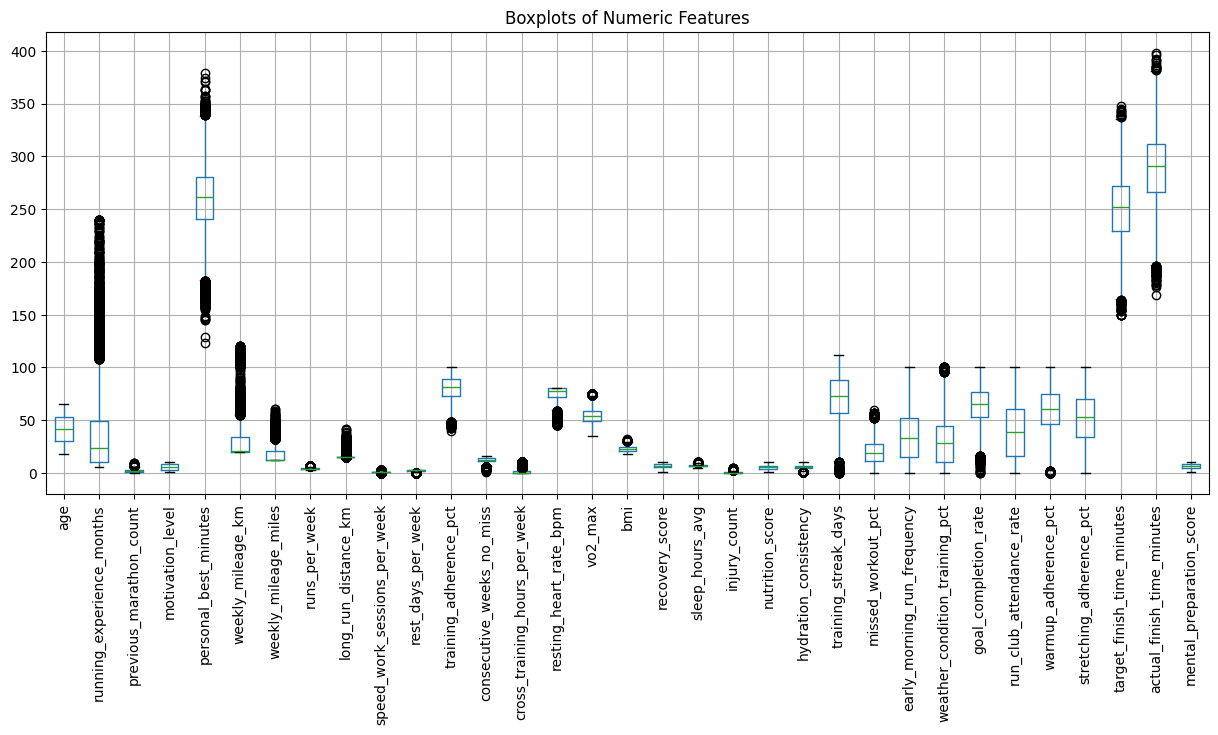

In [28]:
numericdf.boxplot(figsize=(15, 6), rot=90)
plt.title("Boxplots of Numeric Features")
plt.show()

### Incorrect Values

In [29]:
categoric = ['object']

catedf = marathon.select_dtypes(include=categoric)
catedf

,runner_id,gender,training_program,injury_severity,marathon_date,marathon_weather,course_difficulty
0,R043064,Male,Intermediate,None,2025-04-10,Rainy,Mixed
1,R030159,Female,Beginner,Moderate,2025-04-25,Rainy,Mixed
2,R033974,Male,Beginner,None,2025-03-08,Hot,Hilly
3,R088109,Male,Beginner,None,2025-02-23,Sunny,Mixed
4,R042704,Male,Beginner,None,2025-12-24,Sunny,Mixed
...,...,...,...,...,...,...,...
19995,R061225,Male,Advanced,None,2024-09-13,Cloudy,Mixed
19996,R047381,Female,Intermediate,None,2024-10-01,Sunny,Hilly
19997,R068960,Female,Beginner,None,2025-12-25,Cold,Flat
19998,R015312,Female,Beginner,Moderate,2024-09-15,Cloudy,Hilly


In [30]:
catedf['gender'].unique()

array(['Male', 'Female', 'Non-binary'], dtype=object)

In [31]:
catedf['training_program'].unique()

array(['Intermediate', 'Beginner', 'Advanced'], dtype=object)

In [32]:
catedf['injury_severity'].unique()

array(['None', 'Moderate', 'Minor', 'Severe'], dtype=object)

In [33]:
catedf['marathon_weather'].unique()

array(['Rainy', 'Hot', 'Sunny', 'Cloudy', 'Windy', 'Cold'], dtype=object)

In [34]:
catedf['course_difficulty'].unique()

array(['Mixed', 'Hilly', 'Flat'], dtype=object)

### Dropping Columns

In [35]:
marathon = marathon.drop('runner_id', axis=1)
marathon

,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,rest_days_per_week,training_adherence_pct,consecutive_weeks_no_miss,cross_training_hours_per_week,resting_heart_rate_bpm,vo2_max,bmi,recovery_score,sleep_hours_avg,injury_count,injury_severity,nutrition_score,hydration_consistency,training_streak_days,missed_workout_pct,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score
0,64,Male,55,2,Intermediate,5,276.0,20.0,12.4,4,15.0,1,3,74,13,0.8,76,64.072019,24.4,3.9,7.5,0,None,5.0,8.0,26,26,44,43,37,17,12,43,2025-04-10,Rainy,Mixed,250,289.0,7
1,64,Female,8,1,Beginner,8,296.0,20.0,12.4,3,15.0,1,3,78,11,10.0,80,41.223262,22.7,6.1,9.2,1,Moderate,3.0,7.0,95,22,55,3,55,53,62,67,2025-04-25,Rainy,Mixed,295,355.0,7
2,41,Male,6,3,Beginner,10,268.0,20.0,12.4,4,15.0,1,3,80,10,0.1,68,56.696163,27.4,3.1,6.2,0,None,6.0,6.0,89,20,53,53,63,95,59,33,2025-03-08,Hot,Hilly,278,325.0,8
3,43,Male,21,1,Beginner,3,313.0,35.4,22.0,3,15.0,1,3,62,9,0.1,80,53.584944,23.8,6.2,7.2,0,None,5.0,8.0,72,38,32,59,59,54,34,67,2025-02-23,Sunny,Mixed,285,320.0,7
4,48,Male,21,3,Beginner,10,334.0,55.2,34.3,3,26.2,0,3,98,16,0.1,80,44.918921,25.7,4.3,6.9,0,None,8.0,5.0,69,2,93,39,79,64,56,76,2025-12-24,Sunny,Mixed,303,333.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,47,Male,84,1,Advanced,5,251.0,51.2,31.8,4,15.0,1,3,87,14,2.9,80,42.745161,25.3,4.7,6.5,0,None,7.0,8.0,76,13,34,35,88,31,58,74,2024-09-13,Cloudy,Mixed,242,270.0,9
19996,22,Female,28,4,Intermediate,2,239.0,20.9,13.0,5,15.0,2,2,72,10,0.0,80,48.815621,23.5,9.9,7.7,0,None,6.0,5.0,51,28,0,13,58,12,79,33,2024-10-01,Sunny,Hilly,228,267.0,7
19997,29,Female,13,1,Beginner,5,307.0,33.0,20.5,4,15.0,1,3,68,10,0.1,74,57.817647,18.0,9.4,8.9,0,None,6.0,5.0,56,32,0,35,38,60,37,15,2025-12-25,Cold,Flat,292,325.0,5
19998,42,Female,6,4,Beginner,3,301.0,20.0,12.4,5,15.0,1,2,88,11,0.4,80,44.622695,26.8,5.5,7.4,2,Moderate,4.0,1.0,97,12,0,41,62,10,75,63,2024-09-15,Cloudy,Hilly,301,359.0,6


## Data Exploration & Visualisation

In [36]:
sns.set(style='whitegrid')

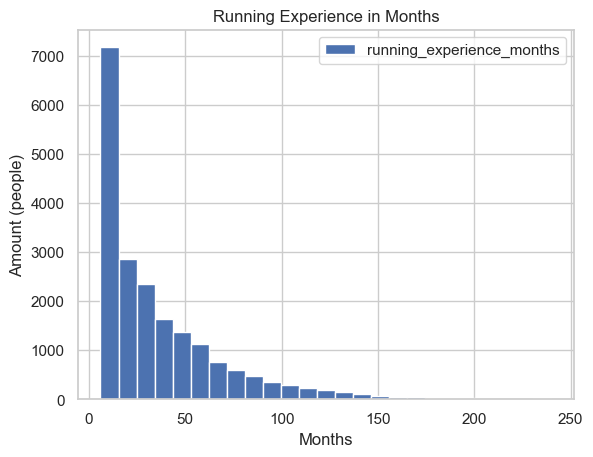

In [37]:
marathon.plot(kind = 'hist', y = 'running_experience_months', bins = 25)
plt.title('Running Experience in Months')
plt.xlabel('Months')
plt.ylabel('Amount (people)')
plt.show()

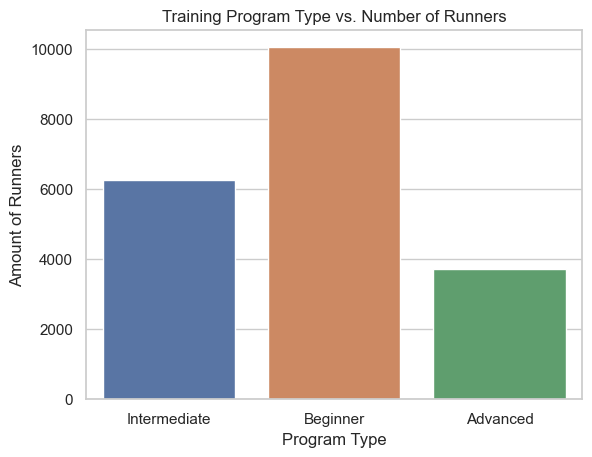

In [38]:
sns.countplot(x='training_program', data=marathon, hue='training_program')

plt.xlabel("Program Type")
plt.ylabel("Amount of Runners")
plt.title("Training Program Type vs. Number of Runners")

plt.show()

In [39]:
months = [0, 50, 100, 150, 200, 250]
group_names = ['0-50', '50-100', '100-150', '150-200', '200-250']

marathon['running_months'] = pd.cut(marathon['running_experience_months'], bins=months, labels=group_names)

In [40]:
personal_times = [120, 180, 240, 300, 360, 400]
time_labels = ['120-180','180-240','240-300','300-360','360-400']

marathon['best_minutes'] = pd.cut(marathon['personal_best_minutes'], bins=personal_times, labels=time_labels)

In [41]:
randomsample = marathon.sample(n = 500, random_state= 50)

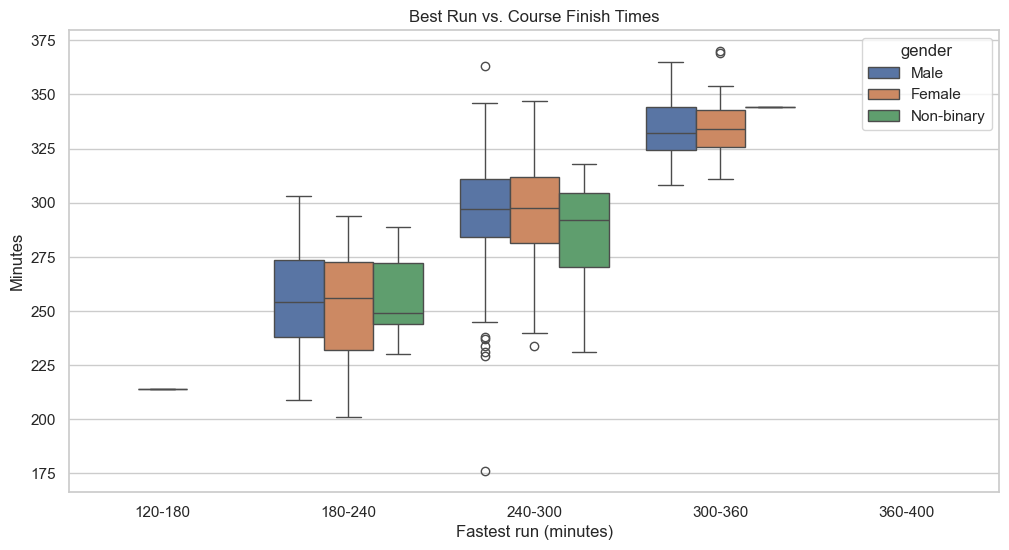

In [42]:
plt.figure(figsize=(12, 6))

sns.boxplot(data = randomsample, x = 'best_minutes', y = 'actual_finish_time_minutes', hue = 'gender')

plt.title('Best Run vs. Course Finish Times')
plt.xlabel('Fastest run (minutes)')
plt.ylabel('Minutes')
plt.show()

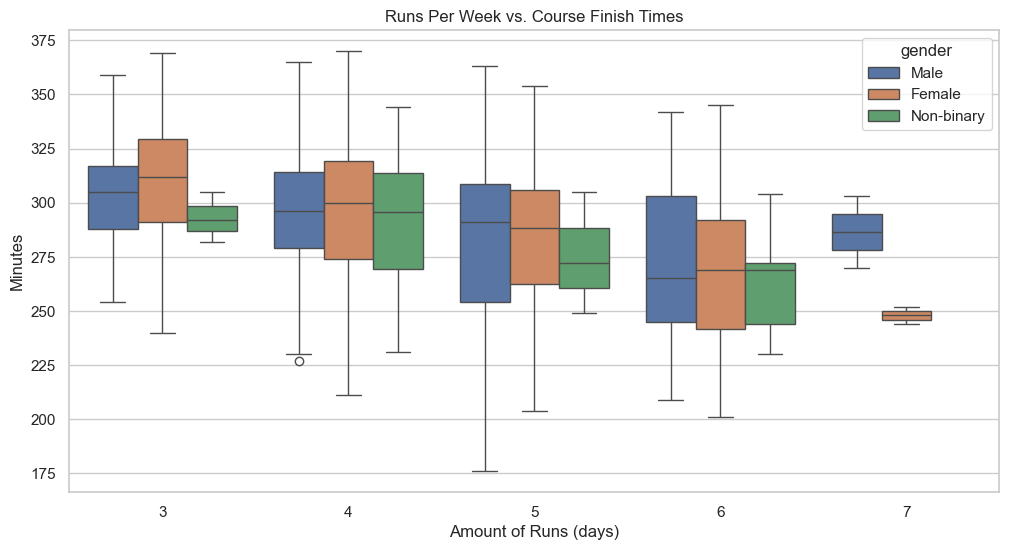

In [43]:
plt.figure(figsize=(12, 6))

sns.boxplot(data = randomsample, x = 'runs_per_week', y = 'actual_finish_time_minutes', hue = 'gender')

plt.title('Runs Per Week vs. Course Finish Times')
plt.xlabel('Amount of Runs (days)')
plt.ylabel('Minutes')
plt.show()

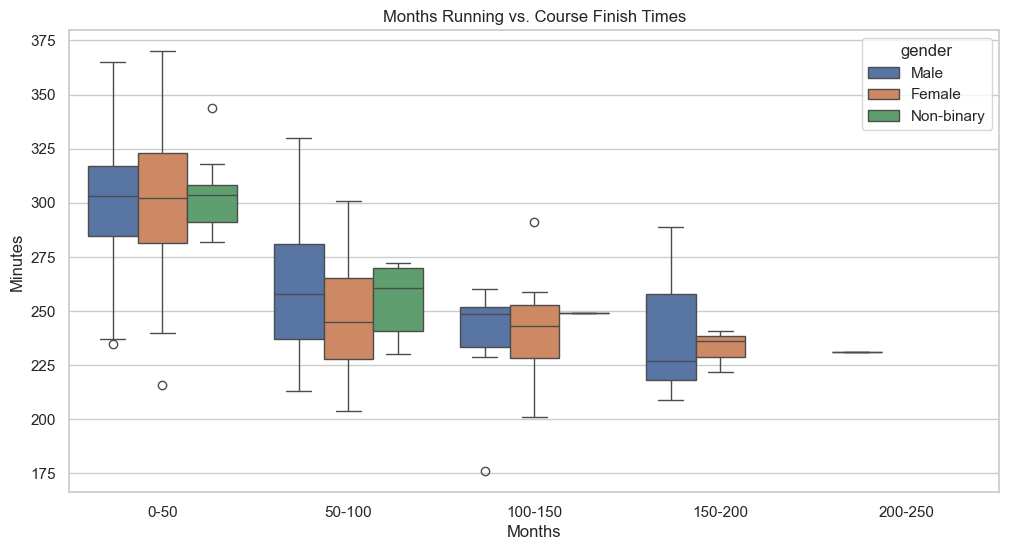

In [44]:
plt.figure(figsize=(12, 6))

sns.boxplot(data = randomsample, x = 'running_months', y = 'actual_finish_time_minutes', hue = 'gender')

plt.title('Months Running vs. Course Finish Times')
plt.xlabel("Months")
plt.ylabel('Minutes')
plt.show()

In [45]:
marathon.head()

,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,rest_days_per_week,training_adherence_pct,consecutive_weeks_no_miss,cross_training_hours_per_week,resting_heart_rate_bpm,vo2_max,bmi,recovery_score,sleep_hours_avg,injury_count,injury_severity,nutrition_score,hydration_consistency,training_streak_days,missed_workout_pct,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,running_months,best_minutes
0,64,Male,55,2,Intermediate,5,276.0,20.0,12.4,4,15.0,1,3,74,13,0.8,76,64.072019,24.4,3.9,7.5,0,None,5.0,8.0,26,26,44,43,37,17,12,43,2025-04-10,Rainy,Mixed,250,289.0,7,50-100,240-300
1,64,Female,8,1,Beginner,8,296.0,20.0,12.4,3,15.0,1,3,78,11,10.0,80,41.223262,22.7,6.1,9.2,1,Moderate,3.0,7.0,95,22,55,3,55,53,62,67,2025-04-25,Rainy,Mixed,295,355.0,7,0-50,240-300
2,41,Male,6,3,Beginner,10,268.0,20.0,12.4,4,15.0,1,3,80,10,0.1,68,56.696163,27.4,3.1,6.2,0,None,6.0,6.0,89,20,53,53,63,95,59,33,2025-03-08,Hot,Hilly,278,325.0,8,0-50,240-300
3,43,Male,21,1,Beginner,3,313.0,35.4,22.0,3,15.0,1,3,62,9,0.1,80,53.584944,23.8,6.2,7.2,0,None,5.0,8.0,72,38,32,59,59,54,34,67,2025-02-23,Sunny,Mixed,285,320.0,7,0-50,300-360
4,48,Male,21,3,Beginner,10,334.0,55.2,34.3,3,26.2,0,3,98,16,0.1,80,44.918921,25.7,4.3,6.9,0,None,8.0,5.0,69,2,93,39,79,64,56,76,2025-12-24,Sunny,Mixed,303,333.0,7,0-50,300-360


# Predicting Marathon Finish Times

### Ordinal/Label Encoding

In [46]:
marathon['gender'] = marathon['gender'].map({'Non-binary':2,'Female': 1, 'Male': 0})
marathon['training_program'] = marathon['training_program'].map({'Advanced':2,'Intermediate': 1, 'Beginner': 0})
marathon['injury_severity'] = marathon['injury_severity'].map({'Severe':3,'Moderate':2,'Minor': 1, 'None' : 0})
marathon['marathon_weather'] = marathon['marathon_weather'].map({'Cold':5,'Windy':4,'Cloudy':3,'Sunny':2,'Hot': 1, 'Rainy': 0})
marathon['course_difficulty'] = marathon['course_difficulty'].map({'Mixed':5,'Hilly': 1, 'Flat': 0})

In [47]:
marathon = marathon.drop(columns=['marathon_date'])

In [48]:
marathon_sample = marathon.sample(n=10000, random_state=999).reset_index(drop=True)
marathon_sample.shape

(10000, 40)

In [49]:
target = marathon_sample['actual_finish_time_minutes']
Data_marathon = marathon_sample.drop(columns=['actual_finish_time_minutes', 'target_finish_time_minutes','running_months',
                                             'best_minutes'])
Data_numpy = Data_marathon.values
X_train, X_test, y_train, y_test = train_test_split(Data_numpy, 
                                                    target, 
                                                    test_size=0.3,
                                                    random_state=999)

In [50]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7000, 36)
(3000, 36)
(7000,)
(3000,)


In [51]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
results = []

linear_model = LinearRegression()

number_of_features = [5, 10, 15, 20, 25, 30, 35]
for n in number_of_features:
    linear_forward = SequentialFeatureSelector(
        LinearRegression(), 
        n_features_to_select=n, 
        direction="forward")

    linear_forward.fit(X_train, y_train)

    X_train_selected = linear_forward.transform(X_train)
    X_test_selected = linear_forward.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append(
        {
            "NumberOfFeatures": n,
            "R2 Score": r2,
            "RMSE": rmse
        }
    )

results_df = pd.DataFrame(results)

results_df

,NumberOfFeatures,R2 Score,RMSE
0,5,0.779498,15.776329
1,10,0.785422,15.562992
2,15,0.785689,15.553280
3,20,0.784726,15.588186
4,25,0.784302,15.603526
5,30,0.784424,15.599117
6,35,0.784317,15.602981


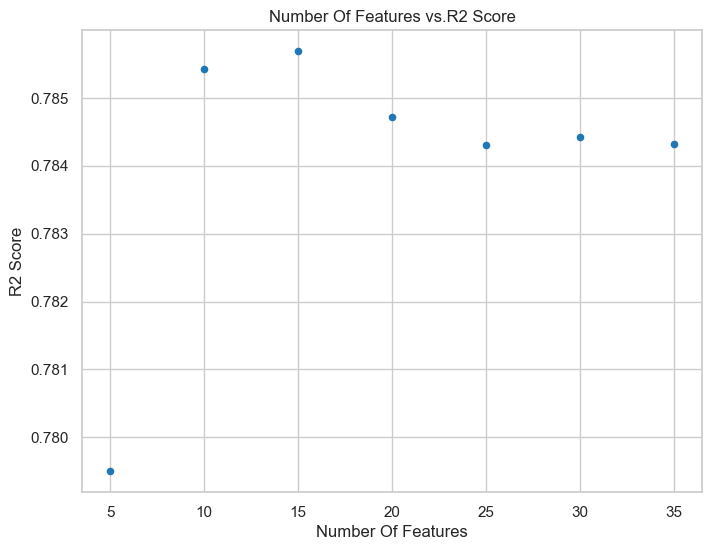

In [52]:
results_df.plot(kind = 'scatter', y = 'R2 Score', x = 'NumberOfFeatures', color = '#1f77b4', figsize=(8, 6))
plt.title('Number Of Features vs.R2 Score')
plt.xlabel('Number Of Features')
plt.ylabel('R2 Score')
plt.show()

In [53]:
linear_forward = SequentialFeatureSelector(
        LinearRegression(), 
        n_features_to_select=15, 
        direction="forward",
        scoring="r2"
)
linear_forward.fit(X_train, y_train)

SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=15,
                          scoring='r2')

In [54]:
feature_selected = linear_forward.get_feature_names_out()
feature_selected 

array(['x2', 'x4', 'x6', 'x7', 'x8', 'x11', 'x13', 'x16', 'x19', 'x22',
       'x23', 'x26', 'x30', 'x34', 'x35'], dtype=object)

In [55]:
feature_numbers = [int(x.replace("x", "")) for x in feature_selected]
feature_numbers

[2, 4, 6, 7, 8, 11, 13, 16, 19, 22, 23, 26, 30, 34, 35]

In [56]:
Data_marathon.iloc[:, feature_numbers].columns

Index(['running_experience_months', 'training_program',
       'personal_best_minutes', 'weekly_mileage_km', 'weekly_mileage_miles',
       'speed_work_sessions_per_week', 'training_adherence_pct',
       'resting_heart_rate_bpm', 'recovery_score', 'injury_severity',
       'nutrition_score', 'missed_workout_pct', 'run_club_attendance_rate',
       'course_difficulty', 'mental_preparation_score'],
      dtype='object')

### Model Fitting & Tuning

#### K nearest neighbour

In [57]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor

cv_method = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=999)

knn_model = KNeighborsRegressor()
knn_params = {
    'n_neighbors': [20],#[1, 3, 5, 10, 15, 20]
    'p': [2],#[1, 2, 3, 4, 5]
    'weights': ["distance"]}#["uniform", "distance"]

grid_search = GridSearchCV(
    estimator=knn_model, 
    param_grid=knn_params, 
    scoring="r2", 
    cv=cv_method)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=999, shuffle=True),
             estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [20], 'p': [2],
                         'weights': ['distance']},
             scoring='r2')

In [58]:
grid_search.score(X_test, y_test)

0.7023646756493547

In [59]:
grid_search.best_score_

np.float64(0.6828830665702499)

In [60]:
best_neighbour = grid_search.best_estimator_

In [61]:
y_pred_KNN = best_neighbour.predict(X_test)

#### Decision Trees

In [62]:
from sklearn.tree import DecisionTreeRegressor

cv_method = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=999)

DT_model = DecisionTreeRegressor(random_state=999) 
DT_params = {
    'max_depth': [7], #[3, 5, 7]
    'min_samples_split': [2], #[2, 5, 10, 15]
    'min_samples_leaf': [8], #[1, 2, 4, 8]
    'max_features': [None] #[None, 'sqrt', 0.7] 
}

DT_grid_search = GridSearchCV(
    estimator=DT_model, 
    param_grid=DT_params, 
    scoring="r2", 
    cv=cv_method,
    n_jobs=-1 
)

DT_grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=999, shuffle=True),
             estimator=DecisionTreeRegressor(random_state=999), n_jobs=-1,
             param_grid={'max_depth': [7], 'max_features': [None],
                         'min_samples_leaf': [8], 'min_samples_split': [2]},
             scoring='r2')

In [63]:
DT_grid_search.best_score_

np.float64(0.7414992974624253)

In [64]:
best_tree = DT_grid_search.best_estimator_

In [65]:
y_pred_DT = best_tree.predict(X_test)

#### Random Forest

In [66]:
from sklearn.ensemble import RandomForestRegressor

cv_method = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=999)

RF_model = RandomForestRegressor(random_state=999) 
RF_params = {
    'max_depth': [12], #[4, 6, 8, 10, 12]
    'min_samples_split': [15], #[2, 5, 10, 15]
    'min_samples_leaf': [1], #[1, 2, 4, 8]
    'max_features': [0.7] #[None, 'sqrt', 0.7]
}

RF_grid_search = GridSearchCV(
    estimator=RF_model, 
    param_grid=RF_params, 
    scoring="r2", 
    cv=cv_method,
    n_jobs=-1 
)

RF_grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=999, shuffle=True),
             estimator=RandomForestRegressor(random_state=999), n_jobs=-1,
             param_grid={'max_depth': [12], 'max_features': [0.7],
                         'min_samples_leaf': [1], 'min_samples_split': [15]},
             scoring='r2')

In [67]:
RF_grid_search.best_score_

np.float64(0.7839086589959305)

In [68]:
best_RF = RF_grid_search.best_estimator_

In [69]:
y_pred_RF = best_RF.predict(X_test)

In [70]:
importances = best_RF.feature_importances_

feature_names = Data_marathon.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head())

                      Feature  Importance
4            training_program    0.286436
2   running_experience_months    0.266621
6       personal_best_minutes    0.260278
22            injury_severity    0.030423
16     resting_heart_rate_bpm    0.012027


#### Plots

In [71]:
import random
np.random.seed(42)
sample = np.random.choice(len(y_test), size=300, replace=False)

y_test_sample = y_test.iloc[sample]

In [72]:
y_pred_KNN_sample = y_pred_KNN[sample]
residuals_KNN = y_test_sample - y_pred_KNN_sample

In [73]:
y_pred_DT_sample = y_pred_DT[sample]
residuals_DT = y_test_sample - y_pred_DT_sample

In [74]:
y_pred_RF_sample = y_pred_RF[sample]
residuals_RF = y_test_sample - y_pred_RF_sample

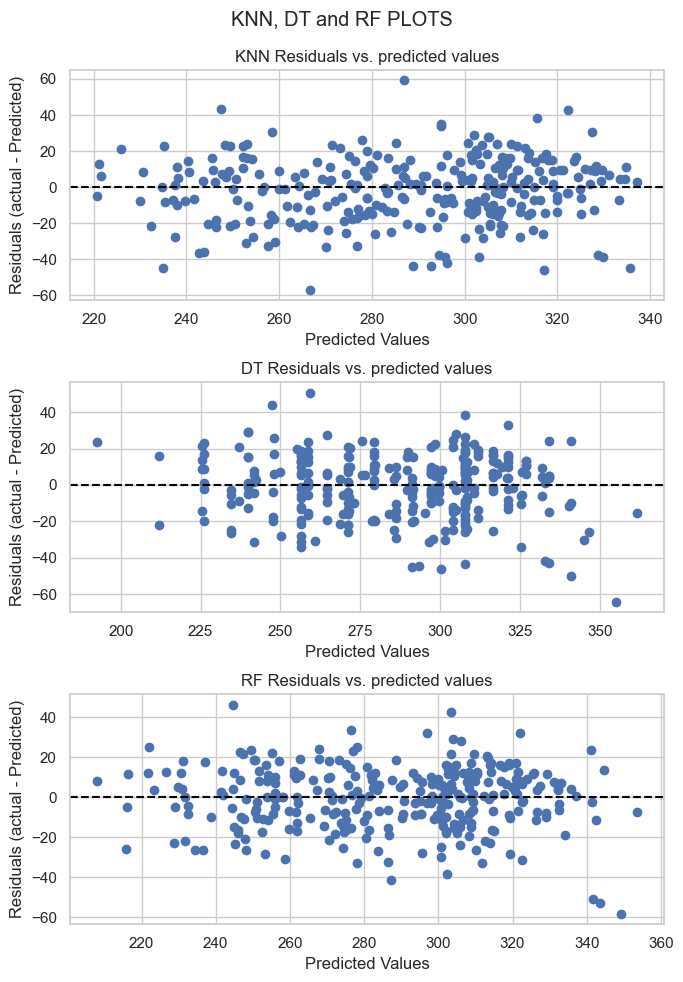

In [75]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 10))
plt.subplot(3,1,1)
plt.scatter(y_pred_KNN_sample, residuals_KNN)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (actual - Predicted)")
plt.title("KNN Residuals vs. predicted values")
plt.axhline(0, linestyle="--", color="black")

plt.subplot(3,1,2)
plt.scatter(y_pred_DT_sample, residuals_DT)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (actual - Predicted)")
plt.title("DT Residuals vs. predicted values")
plt.axhline(0, linestyle="--", color="black")

plt.subplot(3,1,3)
plt.scatter(y_pred_RF_sample, residuals_RF)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (actual - Predicted)")
plt.title("RF Residuals vs. predicted values")
plt.axhline(0, linestyle="--", color="black")

fig.tight_layout()
plt.suptitle("KNN, DT and RF PLOTS")
fig.subplots_adjust(top=0.92)
plt.show()

## Model Comparison

In [76]:
from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_rel

knn_scores = cross_val_score(
    best_neighbour,
    X_train,
    y_train,
    cv=cv_method,
    scoring='r2'
)

dt_scores = cross_val_score(
    best_tree,
    X_train,
    y_train,
    cv=cv_method,
    scoring='r2'
)

rf_scores = cross_val_score(
    best_RF,
    X_train,
    y_train,
    cv=cv_method,
    scoring='r2'
)

print("KNN vs. DT: T stat=", ttest_rel(knn_scores, dt_scores).statistic,"P-value=", ttest_rel(knn_scores, dt_scores).pvalue)
print("KNN vs. RF: T stat=",ttest_rel(knn_scores, rf_scores).statistic,"P-value=", ttest_rel(knn_scores, rf_scores).pvalue)
print("DT vs. RF: T stat=",ttest_rel(dt_scores, rf_scores).statistic,"P-value=",ttest_rel(dt_scores, rf_scores).pvalue)

KNN vs. DT: T stat= -15.777779513501594 P-value= 9.428134289245705e-05
KNN vs. RF: T stat= -27.39642225403416 P-value= 1.0556699684329693e-05
DT vs. RF: T stat= -23.225333940459983 P-value= 2.036830539349743e-05
